# <span style="color:teal"> Lezione 2 </span>
## <span style="color:turquoise"> Esercizio 2.1 </span> 
In questo esercizio è stato chiesto di stimare il valore dell'integrale 
$$I = \int_0^1 \frac{\pi}{2}\cos(\pi x/2) dx = 1$$

attraverso una simulazione Monte Carlo da $M=10^4$ step e da $N=100$ blocchi, confrontando il metodo del campionamento uniforme con la tecnica dell'importance sampling.

1. **Campionamento uniforme**: l'integrale è stato stimato come valor medio della funzione su punti campionati casualmente, estraendo $M$ punti distribuiti uniformemente nell'intervallo $[0,1)$.
$$\int_0^1 f(x) dx \approx \frac{1}{M}\sum_{i=1}^M f(x_i) $$

2. **Importance sampling**: per dimunuire la varianza dello stimatore e ottenere stime più precise si utilizza la tecnica dell'importance sampling. Invece di campionare uniformente, si introduce una densità di probabilità $p(x)$ e si riscrive l'integrale come:
$$\int_0^1 f(x) dx=\int_0^1 \frac{f(x)}{p(x)}\, p(x)  dx \approx \frac{1}{M}\sum_{i=1}^M \frac{f(x_i)}{p(x_i)} $$
    dove i punti $x_i$ sono campionati secondo $p(x)$.

   La scelta migliore sarebbe $p(x) \propto f(x)$, tuttavia questa richiederebbe di conosce già il valore di $I$. Nella pratica è sufficiente scregliere $p(x)$ in modo che approssimi la forma di $f(x)$. Si sceglie quindi la retta normalizzata passante per $(0,1)$ e $(1,0)$, ovvero: $$p(x)=2(1-x)$$

   in modo che sia facilmente invertibile attraverso il metodo della funzione cumulativa, evitando inoltre le eventuali problematicità legate al segno di $p(x)$ che si incontrerebbero ad esempio con lo sviluppo di Taylor centrato in 0.
    Calcolando e invertendo la funzione cumulativa di $p(x)$, $F(y)=\int_0^y p(t) dt$, si ottiene il modo di campionare $x_i\sim p(x)$ a partire da numeri casuali estratti uniformemente:
   $$ x_i = 1 - \sqrt{1-u} \qquad \text{con}\; u\sim \mathcal{U}[0,1]$$

   

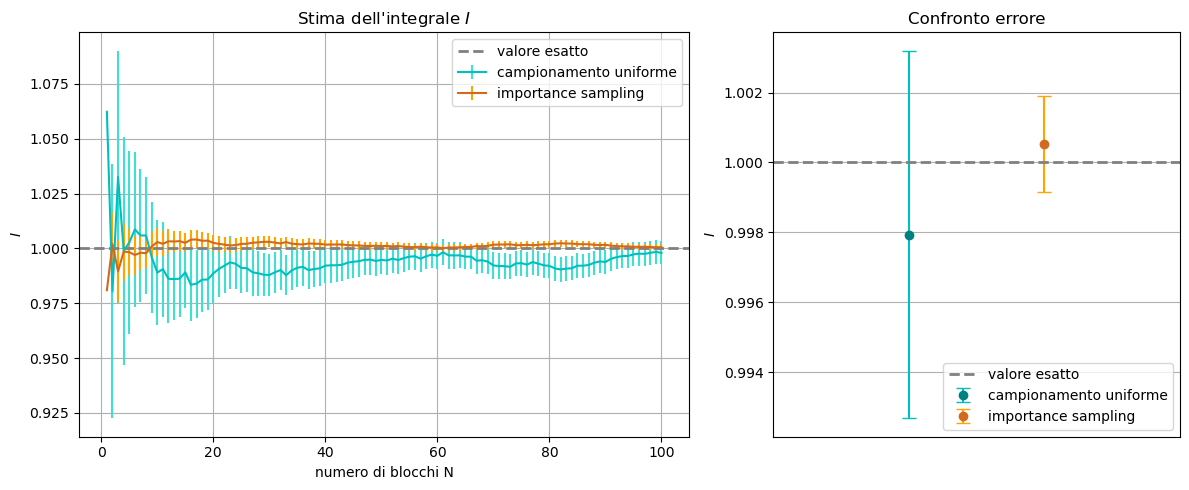

L'errore con il campionamento uniforme è σ = 0.0053
L'errore con l'importance sampling è σ = 0.0014



In [1]:
# stampa grafici e errori
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy import stats             

# -------- carico i dati da file ----------------------------------------------

x = np.arange(1, 101)

dati=np.loadtxt("Esercizio2.1/uniforme.dat")
sum_prog_unif=dati[:,1]
err_prog_unif=dati[:,2]

dati=np.loadtxt("Esercizio2.1/sampling.dat")
sum_prog_sampl=dati[:,1]
err_prog_sampl=dati[:,2]


# -------- faccio i grafici -------------------------------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [3, 2]} )

ax1.errorbar(x,sum_prog_unif,yerr=err_prog_unif, color='c', ecolor='turquoise', label="campionamento uniforme")
ax1.errorbar(x,sum_prog_sampl,yerr=err_prog_sampl, color='chocolate', ecolor='orange', label="importance sampling")
ax1.axhline(y=1, color='grey', linestyle= '--',lw=2, label="valore esatto")
ax1.set_xlabel('numero di blocchi N')
ax1.set_ylabel('$I$')
ax1.set_title("Stima dell'integrale $I$")
ax1.grid(True)
ax1.legend()

ax2.errorbar(1, sum_prog_unif[-1], yerr=err_prog_unif[-1], color='teal', ecolor='c', capsize=5, label="campionamento uniforme", fmt='o')
ax2.errorbar(2, sum_prog_sampl[-1], yerr=err_prog_sampl[-1], color='chocolate', ecolor='orange', capsize=5, label="importance sampling", fmt='o')
ax2.axhline(y=1, color='grey', linestyle= '--',lw=2, label="valore esatto")
ax2.set_ylabel("$I$")
ax2.set_title("Confronto errore")
ax2.set_xlim(0, 3)
ax2.set_xticks([])
ax2.grid(True, axis='y')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()


# -------- stampo i valori finali degli errori ---------------------------------------------------------------------

print(f"L'errore con il campionamento uniforme è σ = {err_prog_unif[-1]:.2g}")
print(f"L'errore con l'importance sampling è σ = {err_prog_sampl[-1]:.2g}")
print()

Nel grafico a sinistra è riportato l'andamento della stima dell'integrale $I$ in funzione del numero di blocchi $N$ per entrambi i metodi. Si osserva che entrambi gli stimatori convergono al valore esatto $I=1$, come atteso dalla legge dei grandi numeri. Con l'importance sampling la convergenza è molto più rapida e le incertezze statistiche sono significativamente minori rispetto al campionamento uniforme, confermando la nostra scelta di $p(x)$.  

Il confronto tra le incertezze finali è maggiormente apprezzabile nel grafico a destra, dove sono riportati i valori stimati con le relative barre d'errore al termine della simulazione. Entrambe le stime sono compatibili con il valore esatto entro 1$\sigma$. L'errore ottenuto con l'importance sampling è circa 4 volte inferiore rispetto a quello del campionamento uniforme, corrispondente a una riduzione dell'errore del $75\%$ circa.

## <span style="color:turquoise"> Esercizio 2.2 </span> 
In questo esercizio è stato chiesto di simulare un random walk tridimensionale di $P=100$ passi con partenza nell'origine attraverso una simulazione Monte Carlo da $M=10^4$ step e da $N=100$ blocchi, confrontando il moto che avviene su un reticolo cubico di passo $a=1$ e quello che avviene in modo continuo nello spazio tridimensionale.

L'obiettivo è calcolare e graficare, per ogni passo i, la distanza quadratica media $\sqrt{\langle |\vec{r}_i|^2 \rangle}$, dove $|r_i|^2=x_i^2+y_i^2+z_i^2$, e verificare se l'andamento ottenuto è compatibile con il comportamento diffusivo atteso $f(P)=k\sqrt{P}$.

1. **Sul reticolo cubico**: ad ogni istante discreto il walker compie un passo spostandosi casualmente avanti o indietro di $a=1$ in una delle tre direzioni principali del reticolo: x, y o z. Lo spostamento è determinato estraendo un numero casuale. Facendo un fit dei nostri dati con $f(P)$ otteniamo un valore di k in accordo con il valore teorico atteso di $k=1$.

2. **Nel continuo**: ad ogni istante discreto il walker compie un passo di lunghezza $a=1$ in una direzione casuale dello spazio tridimensionale. Si campiona uniformemente l'angolo solido tramite $\phi \in [0, 2\pi]$ e $\cos\theta \in [-1, 1]$, in modo da garantire una distribuzione uniforme sulla sfera di raggio $a=1$.

In [2]:
# carico file e stampo k
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy import stats      


def fit_k(x, y, yerr):
    
    # elimina punti con errore nullo
    mask = yerr > 0
    x, y, yerr = x[mask], y[mask], yerr[mask]

    w = 1.0 / yerr**2          # pesi
    sx = np.sqrt(x)            # radice di x
    
    k = np.sum(w * sx * y) / np.sum(w * sx**2)
    k_err = 1.0 / np.sqrt(np.sum(w * sx**2))
    
    return k, k_err

# -------- carico i dati da file ----------------------------------------------

x = np.arange(1, 101)

dati=np.loadtxt("Esercizio2.2/reticolo.dat")
sum_prog_ret=dati[:,1]
err_prog_ret=dati[:,2]

dati=np.loadtxt("Esercizio2.2/continuo.dat")
sum_prog_cont=dati[:,1]
err_prog_cont=dati[:,2]

# -------- faccio e stampo il fit ----------------------------------------------

k_ret, k_err_ret = fit_k(x, sum_prog_ret, err_prog_ret)
k_cont, k_err_cont = fit_k(x, sum_prog_cont, err_prog_cont)

print(f"Reticolo: k={k_ret:.4g} +/- {k_err_ret:.1g}")
print(f"Continuo: k={k_cont:.4g} +/- {k_err_cont:.1g}")

y_fit_ret  = k_ret * np.sqrt(x)
y_fit_cont  = k_cont * np.sqrt(x)


Reticolo: k=0.9992 +/- 0.0004
Continuo: k=0.9994 +/- 0.0004


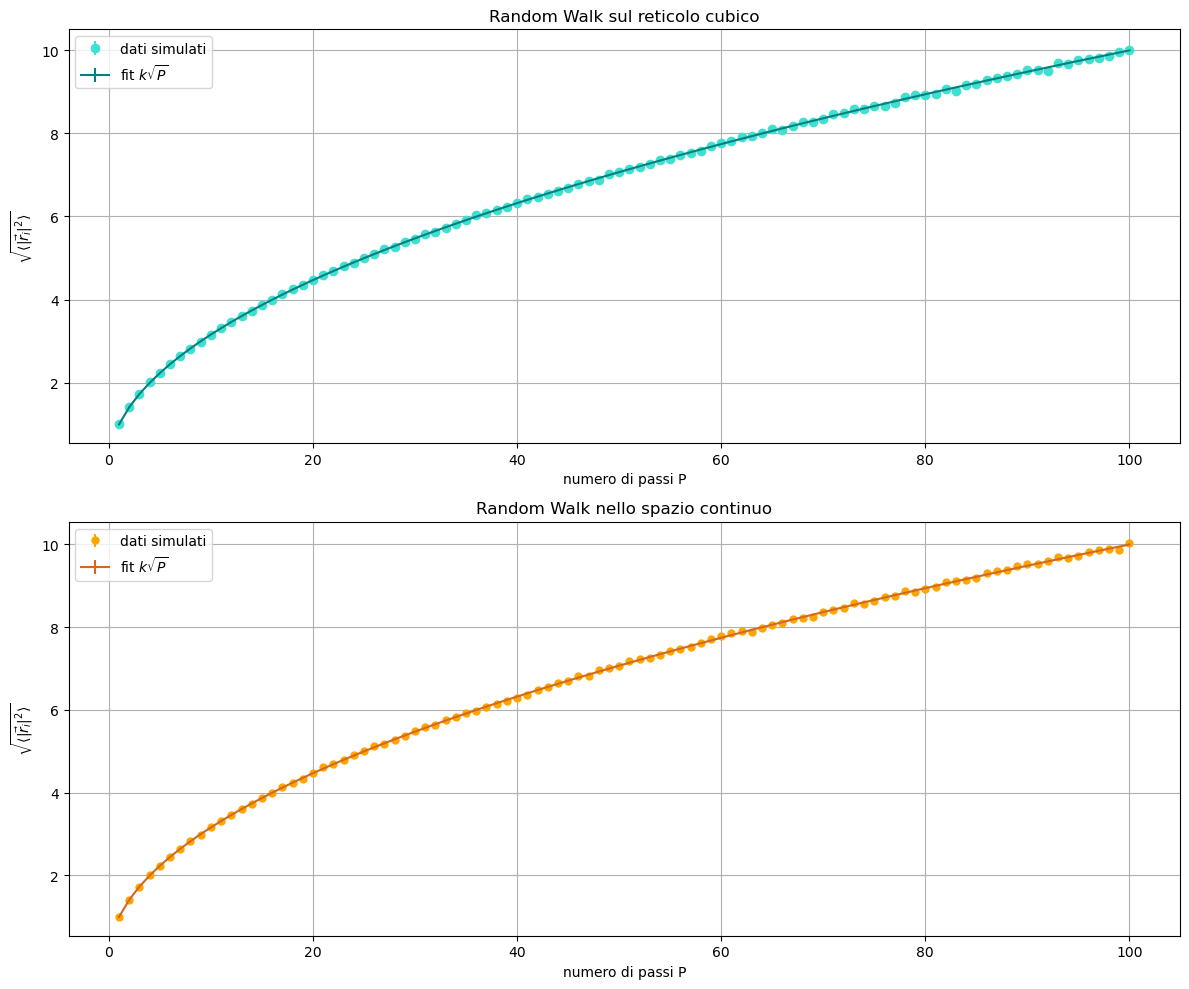

In [3]:
# grafici andamento e fit

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

ax1.errorbar(x,sum_prog_ret,yerr=err_prog_ret, color='turquoise', ecolor='turquoise', label="dati simulati", fmt='o', markersize=6)
ax1.errorbar(x,y_fit_ret,yerr=k_err_ret, color='teal', ecolor='teal', label=r"fit $k\sqrt{P}$")
ax1.set_xlabel('numero di passi P')
ax1.set_ylabel(r"$\sqrt{\langle |\vec{r}_i|^2 \rangle}$")
ax1.set_title("Random Walk sul reticolo cubico")
ax1.grid(True)
ax1.legend()

ax2.errorbar(x,sum_prog_cont,yerr=err_prog_cont, color='orange', ecolor='orange', label="dati simulati", fmt='o', markersize=5)
ax2.errorbar(x,y_fit_cont,yerr=k_err_cont, color='chocolate', ecolor='chocolate', label=r"fit $k\sqrt{P}$")
ax2.set_xlabel('numero di passi P')
ax2.set_ylabel(r"$\sqrt{\langle |\vec{r}_i|^2 \rangle}$")
ax2.set_title("Random Walk nello spazio continuo")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

Nei grafici è rappresentato l'andamento di $\sqrt{\langle |\vec{r}_i|^2 \rangle}$ in funzione del numero di passi $P$. La curva continua rappresenta il fit con la funzione $f(P)=k\sqrt{P}$, mentre i punti sono i valori medi calcolati per ogni passo tramite il data blocking; in blu sono rappresentati i dati per il reticolo cubico, mentre in arancione quelli per lo spazio continuo. Per entrambe le configurazioni c'è un ottimo accordo tra il fit e i dati, confermando che il sistema si comporta in modo diffusivo: il walker si allontana dall'origine in modo proporzionale alla radice dei passi effettuati.

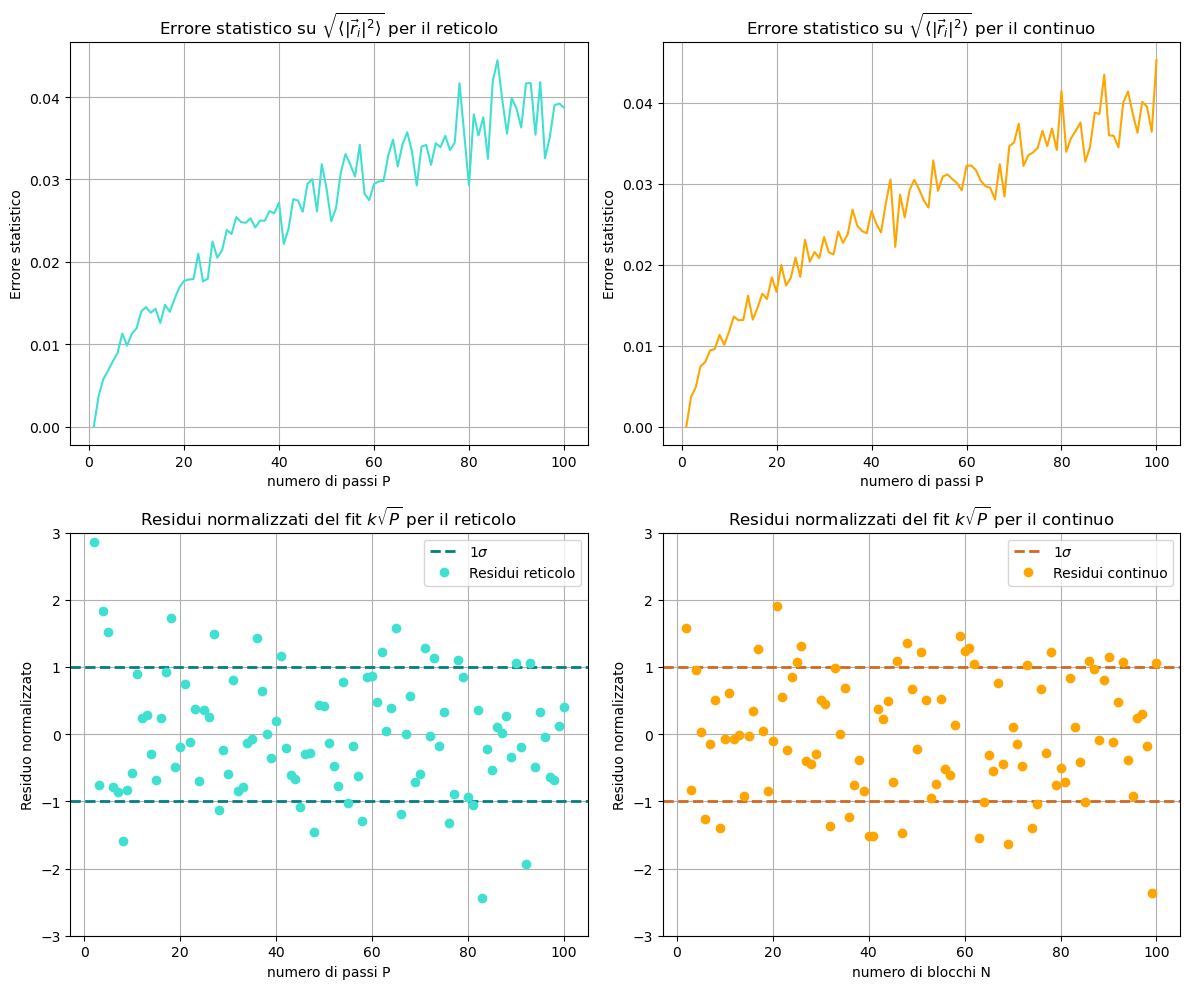

In [6]:
# grafici errore e fit
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

ax1.plot(x,err_prog_ret, color='turquoise', label="campionamento uniforme", markersize=6)
ax1.set_xlabel('numero di passi P')
ax1.set_ylabel('Errore statistico')
ax1.set_title(r"Errore statistico su $\sqrt{\langle |\vec{r}_i|^2 \rangle}$ per il reticolo")
ax1.grid(True)

ax2.plot(x,err_prog_cont, color='orange', label="campionamento uniforme", markersize=6)
ax2.set_xlabel('numero di passi P')
ax2.set_ylabel('Errore statistico')
ax2.set_title(r"Errore statistico su $\sqrt{\langle |\vec{r}_i|^2 \rangle}$ per il continuo")
ax2.grid(True)


mask = err_prog_ret > 0
ax3.axhline(y=1, color='teal', ls='--', lw=2, label=f'1$\sigma$')
ax3.axhline(y=-1, color='teal', ls='--', lw=2)
ax3.plot(x[mask], (sum_prog_ret[mask] - y_fit_ret[mask]) / err_prog_ret[mask],'o', color='turquoise', label="Residui reticolo")
ax3.set_xlabel('numero di passi P')
ax3.set_ylabel("Residuo normalizzato")
ax3.set_ylim(-3, 3)
ax3.set_title(r"Residui normalizzati del fit $k\sqrt{P}$ per il reticolo")
ax3.grid(True)
ax3.legend()

mask = err_prog_cont > 0
ax4.axhline(y=1, color='chocolate', ls='--', lw=2, label=f'1$\sigma$')
ax4.axhline(y=-1, color='chocolate', ls='--', lw=2)
ax4.plot(x[mask], (sum_prog_cont[mask] - y_fit_cont[mask]) / err_prog_cont[mask],'o', color='orange', label="Residui continuo")
ax4.set_xlabel('numero di blocchi N')
ax4.set_ylabel("Residuo normalizzato")
ax4.set_ylim(-3, 3)
ax4.set_title(r"Residui normalizzati del fit $k\sqrt{P}$ per il continuo")
ax4.grid(True)
ax4.legend()


plt.tight_layout()
plt.show()

Nei grafici in alto, a sinistra per il reticolo cubico e a destra per lo spazio continuo, è mostrato l'errore statistico su $\sqrt{\langle |\vec{r}_i|^2 \rangle}$ in funzione del numero di passi $i\in [0,10^2]$. In entrambi i casi si osserva che l'errore cresce all'aumentare di $i$, infatti dopo molti passi le traiettorie dei diversi walker sono maggiormente disperse nello spazio, facendo aumentare la varianza tra un random walk e un altro.

Nei grafici in basso, a sinistra per il reticolo cubico e a destra per lo spazio continuo, sono rappresentati i resisui normalizzati del fit con $k \sqrt{P} $, ovvero la differenza tra i valori simulati e la curva del fit divisi per l'errore statistico. La banda tratteggiata indica la regione $\pm 1\sigma$. In entrambi i casi i residui risultano distribuiti in modo omogeneo e casuale attorno allo zero, con la grande maggioranza dei punti che ricade all'interno della banda  $\pm 1\sigma$ e con solo pochi che ne escono; questo riflette un corretto comportamento di fluttuazioni statistiche.  
Questo risultato conferma che il fit con $ \sqrt{P} $ ben descrive i dati in entrambi i casi e che non sono presenti deviazioni dall'andamento diffusivo.